# 04 — Detector de Bolas (YOLO Multiclasse)

Detecta e classifica todas as bolas da mesa usando um modelo **YOLOv8** treinado com 4 classes:

| ID | Classe |
|---|---|
| 0 | `branca` |
| 1 | `lisa` |
| 2 | `listrada` |
| 3 | `preta` |

**Entrada:** `data/normalized/`  
**Saída:** `data/output/<nome>_balls.json` + `<nome>_viz.png`

---
**Ordem de execução:** rode as células em sequência. A Célula 3 testa em uma imagem única antes de rodar o batch completo.

## Célula 1 — Imports, caminhos e carga do modelo

Carrega o modelo YOLO treinado e define o mapeamento de IDs para nomes de classe.

In [1]:
import os
import cv2
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

CAMINHO_BASE       = os.path.join(os.path.dirname(os.getcwd()), 'data')
CAMINHO_NORMALIZED = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_OUTPUT     = os.path.join(CAMINHO_BASE, 'output')
CAMINHO_MODELO     = os.path.join(CAMINHO_BASE, '..', 'models', 'yolo_deteccao_bolas.pt')

modelo_yolo = YOLO(CAMINHO_MODELO)

NOMES_CLASSES = {0: 'branca', 1: 'lisa', 2: 'listrada', 3: 'preta'}

print('Modelo carregado:', CAMINHO_MODELO)
print('Classes:', NOMES_CLASSES)

Modelo carregado: /home/juliana/Projects/UFSC/visao/SinucaVision/data/../models/yolo_deteccao_bolas.pt
Classes: {0: 'branca', 1: 'lisa', 2: 'listrada', 3: 'preta'}


## Célula 2 — Função de detecção

`detectar_bolas_e_cacapas(imagem, modelo, conf)` recebe uma imagem BGR já normalizada pela homografia e devolve um dicionário com duas listas:

- **`bolas`**: `{tipo, x, y, raio, confianca}` para cada bola detectada pelo YOLO.
- **`cacapas`**: 6 posições fixas calculadas pelas margens da imagem normalizada (derivadas da homografia — independem de detecção).

O parâmetro `conf` controla o limiar de confiança (padrão `0.35`).

In [2]:
def detectar_bolas_e_cacapas(imagem, modelo, conf=0.45, iou=0.35):
    """Roda o YOLO na imagem e retorna bolas + caçapas no formato padrão do pipeline."""
    
    altura, largura = imagem.shape[:2]
    resultados = {'cacapas': [], 'bolas': []}

    # Caçapas — posições fixas derivadas da homografia (não mudam)
    margem_x = int(largura * 0.02)
    margem_y = int(altura * 0.04)
    resultados['cacapas'] = [
        {'posicao': 'superior_esq',  'x': margem_x,            'y': margem_y},
        {'posicao': 'superior_meio', 'x': largura // 2,         'y': margem_y},
        {'posicao': 'superior_dir',  'x': largura - margem_x,   'y': margem_y},
        {'posicao': 'inferior_esq',  'x': margem_x,             'y': altura - margem_y},
        {'posicao': 'inferior_meio', 'x': largura // 2,         'y': altura - margem_y},
        {'posicao': 'inferior_dir',  'x': largura - margem_x,   'y': altura - margem_y},
    ]

    # Inferência YOLO — ele detecta e classifica 
    pred = modelo.predict(imagem, conf=conf, iou=iou, verbose=False)[0]

    for box in pred.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(largura, x2), min(altura, y2)

        classe_id = int(box.cls[0])
        tipo      = NOMES_CLASSES.get(classe_id, 'lisa')  # fallback seguro
        cx        = (x1 + x2) // 2
        cy        = (y1 + y2) // 2
        raio      = max((x2 - x1), (y2 - y1)) // 2

        resultados['bolas'].append({
            'tipo':      tipo,
            'x':         cx,
            'y':         cy,
            'raio':      raio,
            'confianca': round(float(box.conf[0]), 3),
        })

    return resultados

## Célula 3 — Teste em imagem única

Roda a detecção em uma imagem específica, exibe o resultado visualmente e salva o JSON.

Altere `nome_ficheiro` para testar em uma imagem.

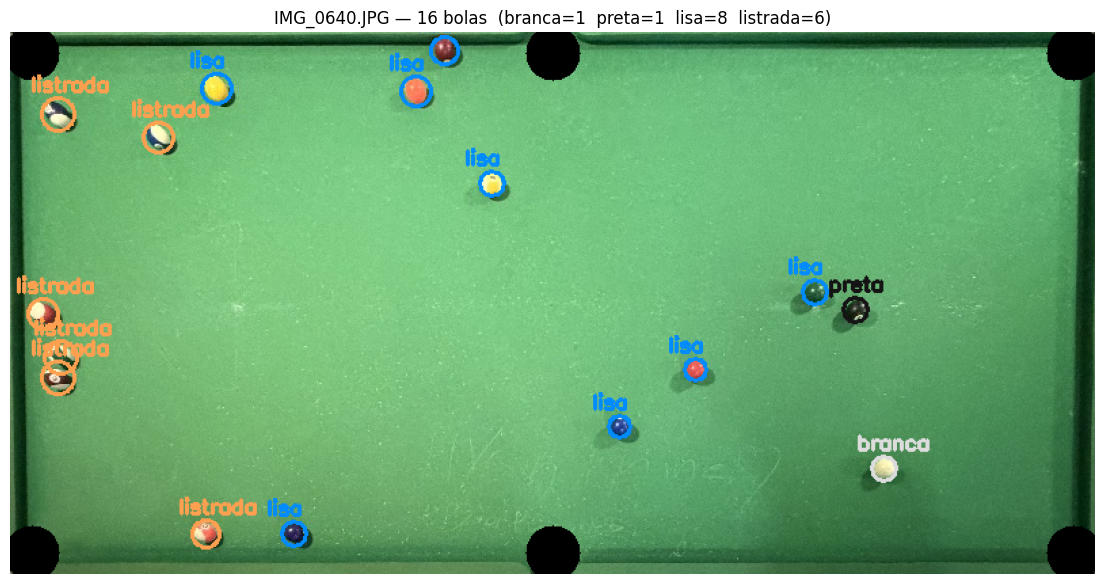

Salvo: /home/juliana/Projects/UFSC/visao/SinucaVision/data/output/IMG_0640_balls.json


In [3]:
nome_ficheiro = 'IMG_0640.JPG'
nome_base     = os.path.splitext(nome_ficheiro)[0]
caminho_img   = os.path.join(CAMINHO_NORMALIZED, nome_ficheiro)
imagem        = cv2.imread(caminho_img)

dados = detectar_bolas_e_cacapas(imagem, modelo_yolo)

COR_TIPO = {
    'branca':   (220, 220, 220),
    'preta':    (20,  20,  20 ),
    'lisa':     (255, 140,  0 ),
    'listrada': (80,  160, 255),
}

vis = imagem.copy()

for cacapa in dados['cacapas']:
    cv2.circle(vis, (cacapa['x'], cacapa['y']), 20, (0, 0, 0), -1)

for bola in dados['bolas']:
    cx, cy, raio, tipo = bola['x'], bola['y'], bola['raio'], bola['tipo']
    cor = COR_TIPO.get(tipo, (0, 255, 0))
    cv2.circle(vis, (cx, cy), raio, cor, 2)
    cv2.putText(vis, tipo, (cx - 20, cy - raio - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

n_b = sum(1 for b in dados['bolas'] if b['tipo'] == 'branca')
n_p = sum(1 for b in dados['bolas'] if b['tipo'] == 'preta')
n_l = sum(1 for b in dados['bolas'] if b['tipo'] == 'lisa')
n_s = sum(1 for b in dados['bolas'] if b['tipo'] == 'listrada')

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'{nome_ficheiro} — {len(dados["bolas"])} bolas  '
          f'(branca={n_b}  preta={n_p}  lisa={n_l}  listrada={n_s})')
plt.axis('off')
plt.show()

# Salva JSON
os.makedirs(CAMINHO_OUTPUT, exist_ok=True)
caminho_json = os.path.join(CAMINHO_OUTPUT, f'{nome_base}_balls.json')
with open(caminho_json, 'w', encoding='utf-8') as f:
    json.dump(dados, f, indent=4, ensure_ascii=False)
print(f'Salvo: {caminho_json}')

## Célula 4 — Processamento em lote

Processa todas as imagens em `data/normalized/` e salva um JSON por imagem em `data/output/<nome>_balls.json`.

In [4]:
imagens = sorted(
    glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.JPG')) +
    glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.jpg'))
)
print(f'Imagens encontradas: {len(imagens)}')

for caminho_img in imagens:
    nome_ficheiro = os.path.basename(caminho_img)
    nome_base     = os.path.splitext(nome_ficheiro)[0]
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        print(f'[ERRO] {nome_ficheiro}')
        continue

    dados   = detectar_bolas_e_cacapas(imagem, modelo_yolo)
    bolas   = dados['bolas']
    n_b = sum(1 for b in bolas if b['tipo'] == 'branca')
    n_p = sum(1 for b in bolas if b['tipo'] == 'preta')
    n_l = sum(1 for b in bolas if b['tipo'] == 'lisa')
    n_s = sum(1 for b in bolas if b['tipo'] == 'listrada')

    os.makedirs(CAMINHO_OUTPUT, exist_ok=True)
    caminho_json = os.path.join(CAMINHO_OUTPUT, f'{nome_base}_balls.json')
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(dados, f, indent=4, ensure_ascii=False)

    aviso = '' if n_b == 1 else '  ⚠'
    print(f'{nome_ficheiro}: {len(bolas)} bolas '
          f'(B={n_b} P={n_p} L={n_l} S={n_s}){aviso}')

print(f'\nConcluído. JSONs em data/output')

Imagens encontradas: 53
IMG_0640.JPG: 16 bolas (B=1 P=1 L=8 S=6)
IMG_0641.JPG: 16 bolas (B=1 P=1 L=7 S=7)


IMG_0642.JPG: 16 bolas (B=1 P=1 L=7 S=7)


IMG_0643.JPG: 15 bolas (B=1 P=1 L=6 S=7)
IMG_0645.JPG: 15 bolas (B=1 P=1 L=6 S=7)
IMG_0646.JPG: 15 bolas (B=1 P=1 L=6 S=7)


IMG_0647.JPG: 3 bolas (B=1 P=1 L=1 S=0)


IMG_0649.JPG: 3 bolas (B=1 P=1 L=1 S=0)
IMG_0650.JPG: 3 bolas (B=1 P=1 L=1 S=0)


...

IMG_1068.JPG: 11 bolas (B=1 P=1 L=5 S=4)
IMG_1069.JPG: 9 bolas (B=1 P=1 L=3 S=4)


IMG_1070.JPG: 9 bolas (B=1 P=1 L=3 S=4)


IMG_1071.JPG: 15 bolas (B=1 P=1 L=7 S=6)
IMG_1072.JPG: 15 bolas (B=1 P=1 L=7 S=6)


IMG_1073.JPG: 14 bolas (B=1 P=1 L=6 S=6)


IMG_1074.JPG: 13 bolas (B=1 P=1 L=6 S=5)

Concluído. JSONs em data/output


## Célula 5 — Visualização em lote

Lê todos os JSONs gerados na Célula 4 e salva uma imagem `_viz.png` por resultado, com as bolas numeradas e as caçapas marcadas.

Execute somente após a Célula 4 ter concluído.

In [5]:
arquivos_json = sorted(glob.glob(
    os.path.join(CAMINHO_OUTPUT, '*_balls.json')))
print(f'JSONs encontrados: {len(arquivos_json)}')

COR_TIPO = {
    'branca':   (220, 220, 220),
    'preta':    (20,  20,  20 ),
    'lisa':     (255, 140,  0 ),
    'listrada': (80,  160, 255),
}

for caminho_json in arquivos_json:
    nome_base   = os.path.basename(caminho_json).replace('_balls.json', '')
    pasta_saida = CAMINHO_OUTPUT

    caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.JPG')
    if not os.path.exists(caminho_img):
        caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.jpg')
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        continue

    with open(caminho_json) as f:
        dados = json.load(f)

    bolas = dados['bolas']
    n_b = sum(1 for b in bolas if b['tipo'] == 'branca')
    n_p = sum(1 for b in bolas if b['tipo'] == 'preta')
    n_l = sum(1 for b in bolas if b['tipo'] == 'lisa')
    n_s = sum(1 for b in bolas if b['tipo'] == 'listrada')

    vis = cv2.cvtColor(imagem.copy(), cv2.COLOR_BGR2RGB)

    for cacapa in dados['cacapas']:
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (30, 30, 30), -1)
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (180, 180, 180), 2)

    for idx, bola in enumerate(bolas, 1):
        cx, cy = bola['x'], bola['y']
        raio   = bola.get('raio', 15)
        cor    = COR_TIPO.get(bola['tipo'], (200, 200, 200))
        cv2.circle(vis, (cx, cy), raio + 3, cor, 2)
        cv2.putText(vis, str(idx), (cx - 5, cy - raio - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, cor, 1, cv2.LINE_AA)

    aviso = '' if n_b == 1 else 'BRANCA NÃO DETECTADA / DUPLICADA'
    titulo = (f'{nome_base}  |  {len(bolas)} bolas  '
              f'(branca={n_b}  preta={n_p}  lisa={n_l}  listrada={n_s}){aviso}')

    plt.figure(figsize=(12, 7))
    plt.imshow(vis)
    plt.title(titulo, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    caminho_viz = os.path.join(pasta_saida, f'{nome_base}_viz.png')
    plt.savefig(caminho_viz, dpi=130, bbox_inches='tight')
    plt.close()
    print(f'{nome_base}_viz.png')

print('Visualizações salvas em data/output/<nome>/')

JSONs encontrados: 53


IMG_0640_viz.png


IMG_0641_viz.png


IMG_0642_viz.png


IMG_0643_viz.png


...

IMG_1070_viz.png


IMG_1071_viz.png


IMG_1072_viz.png


IMG_1073_viz.png


IMG_1074_viz.png
Visualizações salvas em data/output/<nome>/
